In [49]:
import glob
import os

import cv2
import numpy as np
from matplotlib import pyplot as plt
from ultralytics import YOLO
import math
import seaborn as sns

In [50]:
INT_TO_CLASS_NAMES = {
    0: "Pedestrian",
    1: "Cyclist",
    2: "Car"
}
CLASS_NAMES_TO_INT = {
    "Pedestrian" : 0,
    "Cyclist" : 1,
    "Car" : 2
}

# Helper funcitons

In [ ]:
def iou(boxA, boxB):
    # Simple IoU function
    x1a, y1a, x2a, y2a = boxA
    x1b, y1b, x2b, y2b = boxB

    xi1 = max(x1a, x1b)
    yi1 = max(y1a, y1b)
    xi2 = min(x2a, x2b)
    yi2 = min(y2a, y2b)

    inter_w = max(0.0, xi2 - xi1)
    inter_h = max(0.0, yi2 - yi1)
    inter = inter_w * inter_h

    areaA = max(0.0, x2a - x1a) * max(0.0, y2a - y1a)
    areaB = max(0.0, x2b - x1b) * max(0.0, y2b - y1b)
    union = areaA + areaB - inter + 1e-8

    return inter / union


def merge_person_bicycle(dets, iou_thresh=0.1):
    
    person_idx = [i for i, d in enumerate(dets) if d["class_id"] == 0]
    bike_idx   = [i for i, d in enumerate(dets) if d["class_id"] == 1]

    used_person = set()
    used_bike = set()
    pairs = []

    # Pair each person with the best-overlapping bicycle
    for pi in person_idx:
        best_j = None
        best_i = 0.0
        
        for bj in bike_idx:
            if bj in used_bike:
                continue
            i = iou(dets[pi]["bbox"], dets[bj]["bbox"])

            if i > best_i:
                best_i = i
                best_j = bj

        if best_j is not None and best_i >= iou_thresh:
            used_person.add(pi)
            used_bike.add(best_j)
            pairs.append((pi, best_j))

    # Keep all detections that are NOT part of a merged person+bike pair
    new_dets = []
    for idx, d in enumerate(dets):
        if idx in used_person or idx in used_bike:
            continue
        new_dets.append(d)

    # Add merged cyclist boxes (class_id = 1 to match GT Cyclist)
    for pi, bj in pairs:
        x1p, y1p, x2p, y2p = dets[pi]["bbox"]
        x1b, y1b, x2b, y2b = dets[bj]["bbox"]
        mx1 = min(x1p, x1b)
        my1 = min(y1p, y1b)
        mx2 = max(x2p, x2b)
        my2 = max(y2p, y2b)
        new_dets.append({
            "class_id": 1,               # treat as Cyclist
            "bbox": (mx1, my1, mx2, my2)
        })

    return new_dets


In [ ]:
# Helper function to read the labels from each of the sequences
def load_gt_for_frame(labels_path, frame_id):

    class_map = CLASS_NAMES_TO_INT
    gts = []

    # We split each line into parts, which should be on the format:
    # frame, id, type, trunc, occ, alpha, x1, y1, x2, y2, ...

    with open(labels_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 10:
                continue

            fid = int(parts[0])
            if fid != frame_id:
                continue

            name = parts[2]
            if name not in class_map:
                continue

            class_id = class_map[name]

            x1 = float(parts[6])
            y1 = float(parts[7])
            x2 = float(parts[8])
            y2 = float(parts[9])

            gts.append({"class_id": class_id, "bbox": (x1, y1, x2, y2)})

    return gts


def run_yolo(frame_path, model, conf_thres=0.5):

    result = model(frame_path, conf=conf_thres, verbose=False)[0]
    dets = []

    for xyxy, cls in zip(result.boxes.xyxy.cpu().numpy(),
                         result.boxes.cls.cpu().numpy()):
        cls = int(cls)
        if cls not in (0, 1, 2):    # person, bicycle, car
            continue
        x1, y1, x2, y2 = xyxy
        dets.append({
            "class_id": cls,
            "bbox": (float(x1), float(y1), float(x2), float(y2))
        })

    # Checks if there is a large overlap of bounding 
    # boxes between a pedestrian and a bicycle
    dets = merge_person_bicycle(dets)

    return dets

In [53]:
def evaluate_frame(frame_path, frame_id, labels_path, model,
                   iou_thresh=0.4, conf_thres=0.5):
    
    gts = load_gt_for_frame(labels_path, frame_id)
    dets = run_yolo(frame_path, model, conf_thres)

    matched_dets = set()
    matches_info = []
    num_correct = 0
    num_wrong = 0

    for gi, gt in enumerate(gts): # Loop through all grount thruths
        best_i = 0.0
        best_det_idx = None
        gt_box = gt["bbox"]

        for j, det in enumerate(dets): # Loop through each YOLO detection
            if j in matched_dets:
                continue

            i = iou(gt_box, det["bbox"]) # Calculate IoU
            if i > best_i:
                best_i = i
                best_det_idx = j

        # If the IoU betwen a YOLO pred and GT is over the threshold,
        # we say they're a match and evalutate classification on the example
        if best_det_idx is not None and best_i >= iou_thresh:
            matched_dets.add(best_det_idx)
            det = dets[best_det_idx]
            is_correct = (det["class_id"] == gt["class_id"])
            matches_info.append({
                "gt_idx": gi,
                "det_idx": best_det_idx,
                "correct": is_correct
            })
            if is_correct:
                num_correct += 1
            else:
                num_wrong += 1

    return num_correct, num_wrong, len(gts), len(matches_info), matches_info

In [ ]:
def visualize_matches(frame_path, frame_id, labels_path, model, matches_info,
                      show_only_incorrect=False):
    
    img = cv2.imread(frame_path)
    gts = load_gt_for_frame(labels_path, frame_id)
    dets = run_yolo(frame_path, model)

    matched_gt = {m["gt_idx"]: m for m in matches_info}
    matched_det_idx = {m["det_idx"] for m in matches_info}

    # For visualization in the, we added this part to only show the
    # wrongly predicted boxes, without it beeing clutterd
    if show_only_incorrect:
        for m in matches_info:
            if not m["correct"]:
                gi = m["gt_idx"]
                di = m["det_idx"]

                gt = gts[gi]
                det = dets[di]

                # GT box (yellow)
                x1, y1, x2, y2 = map(int, gt["bbox"])
                cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,255), 3)
                cv2.putText(img,
                            f"GT:{INT_TO_CLASS_NAMES[gt['class_id']]}",
                            (x1, y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                            (0,255,255), 2)

                # YOLO box (blue)
                dx1, dy1, dx2, dy2 = map(int, det["bbox"])
                cv2.rectangle(img, (dx1, dy1), (dx2, dy2), (255,0,0), 3)
                cv2.putText(img,
                            f"Pred:{INT_TO_CLASS_NAMES[det['class_id']]}",
                            (dx1, dy1-10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7,
                            (255,0,0), 2)

                break  # only show ONE incorrect match

        return img

    # GT boxes
    for gi, gt in enumerate(gts):
        x1, y1, x2, y2 = map(int, gt["bbox"])
        if gi in matched_gt:
            det_idx = matched_gt[gi]["det_idx"]
            det = dets[det_idx]

            gt_class = INT_TO_CLASS_NAMES[gt["class_id"]]
            pred_class = INT_TO_CLASS_NAMES[det["class_id"]]

            if matched_gt[gi]["correct"]:
                color = (0, 0, 255)      # red
            else:
                color = (0, 255, 255)    # yellow
            label = f"GT:{gt_class}  Pred:{pred_class}"

        else:
            color = (0, 255, 0)          # green
            label = f"GT:{INT_TO_CLASS_NAMES[gt['class_id']]} (missed)"

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, label, (x1, max(0,y1-10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    # YOLO unmatched boxes (blue)
    for j, det in enumerate(dets):
        if j in matched_det_idx:
            continue
        
        x1, y1, x2, y2 = map(int, det["bbox"])
        cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)
        cv2.putText(img, f"Pred:{INT_TO_CLASS_NAMES[det['class_id']]}",
                    (x1, max(0,y1-10)), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (255,0,0), 2)

    return img

# Main Cell

In [55]:
def evaluate_sequence(img_folder, labels_path, model):
    img_paths = sorted(glob.glob(img_folder))

    total_correct = 0
    total_wrong = 0
    total_gt = 0
    total_matched = 0

    # Per-class statistics
    per_class_correct   = {0: 0, 1: 0, 2: 0}
    per_class_wrong     = {0: 0, 1: 0, 2: 0}
    per_class_total_gt  = {0: 0, 1: 0, 2: 0}

    # Confusion matrix [GT, Pred]
    confusion = np.zeros((3, 3), dtype=int)

    print(f"\nEvaluating {img_folder}")

    for frame_path in img_paths:
        filename = os.path.basename(frame_path)
        frame_id = int(os.path.splitext(filename)[0])

        correct, wrong, num_gt, num_matched, matches_info = evaluate_frame(
            frame_path, frame_id, labels_path, model
        )

        # Load GT's and YOLO 
        gts = load_gt_for_frame(labels_path, frame_id)
        dets = run_yolo(frame_path, model)

        # Count GT per class
        for gt in gts:
            per_class_total_gt[gt["class_id"]] += 1

        # Count matches per class and create confusion matrix
        matched_gt_idxs = set()
        for m in matches_info:
            gi = m["gt_idx"]
            di = m["det_idx"]

            gt_class = gts[gi]["class_id"]
            pred_class = dets[di]["class_id"]

            matched_gt_idxs.add(gi)

            confusion[gt_class, pred_class] += 1  # record match

            if m["correct"]:
                per_class_correct[gt_class] += 1
            else:
                per_class_wrong[gt_class] += 1

        # Confution matrix is only for classification which we only
        # do for matched bounding boxes
        for gi, gt in enumerate(gts):
            if gi not in matched_gt_idxs:
                pass

        total_correct += correct
        total_wrong += wrong
        total_gt += num_gt
        total_matched += num_matched

    print("\nPER-CLASS RESULTS")
    for cid in [0, 1, 2]:
        total = per_class_total_gt[cid]
        c = per_class_correct[cid]
        w = per_class_wrong[cid]
        missed = total - (c + w)
        print(f"\nClass: {INT_TO_CLASS_NAMES[cid]}")
        print(f"  GT total:      {total}")
        print(f"  Correct:       {c}")
        print(f"  Wrong:         {w}")
        print(f"  Missed (FN):   {missed}")

    # Return stats
    return (
        total_correct,
        total_wrong,
        total_gt,
        total_matched,
        per_class_correct,
        per_class_wrong,
        per_class_total_gt,
        confusion
    )


# Paths
img_folder_seq_2 = "34759_final_project_rect/seq_02/image_02/data/*.png"
labels_path_seq_2 = "34759_final_project_rect/seq_02/labels.txt"

img_folder_seq_1 = "34759_final_project_rect/seq_01/image_02/data/*.png"
labels_path_seq_1 = "34759_final_project_rect/seq_01/labels.txt"

model = YOLO("yolov8n.pt")

(c1, w1, gt1, m1,
 pc_corr1, pc_wrong1, pc_gt1, conf1) = evaluate_sequence(img_folder_seq_2, labels_path_seq_2, model)

(c2, w2, gt2, m2,
 pc_corr2, pc_wrong2, pc_gt2, conf2) = evaluate_sequence(img_folder_seq_1, labels_path_seq_1, model)


print("\nTOTALS")
print("GT:      ", gt1 + gt2)
print("Matched: ", m1 + m2)
print("Correct: ", c1 + c2)
print("Wrong:   ", w1 + w2)

# Combined per-class
combined_per_class_correct = {cid: pc_corr1[cid] + pc_corr2[cid] for cid in [0, 1, 2]}
combined_per_class_wrong   = {cid: pc_wrong1[cid] + pc_wrong2[cid] for cid in [0, 1, 2]}
combined_per_class_gt      = {cid: pc_gt1[cid] + pc_gt2[cid] for cid in [0, 1, 2]}

print("\nPER-CLASS RESULTS COMBINED BOTH SEQUENCE")
for cid in [0, 1, 2]:
    total = combined_per_class_gt[cid]
    c = combined_per_class_correct[cid]
    w = combined_per_class_wrong[cid]
    missed = total - (c + w)
    print(f"\nClass: {INT_TO_CLASS_NAMES[cid]}")
    print(f"  GT total:    {total}")
    print(f"  Correct:     {c}")
    print(f"  Wrong:       {w}")
    print(f"  Missed (FN): {missed}")


# Confusion matrix
combined_confusion = conf1 + conf2

print("\nCONFUSION MATRIX")
print("Rows = GT, Cols = Pred")
print(combined_confusion)


Evaluating 34759_final_project_rect/seq_02/image_02/data/*.png

PER-CLASS RESULTS

Class: Pedestrian
  GT total:      2027
  Correct:       793
  Wrong:         0
  Missed (FN):   1234

Class: Cyclist
  GT total:      272
  Correct:       31
  Wrong:         49
  Missed (FN):   192

Class: Car
  GT total:      836
  Correct:       141
  Wrong:         0
  Missed (FN):   695

Evaluating 34759_final_project_rect/seq_01/image_02/data/*.png

PER-CLASS RESULTS

Class: Pedestrian
  GT total:      782
  Correct:       549
  Wrong:         4
  Missed (FN):   229

Class: Cyclist
  GT total:      101
  Correct:       0
  Wrong:         1
  Missed (FN):   100

Class: Car
  GT total:      0
  Correct:       0
  Wrong:         0
  Missed (FN):   0

TOTALS
GT:       4018
Matched:  1568
Correct:  1514
Wrong:    54

PER-CLASS RESULTS COMBINED BOTH SEQUENCE

Class: Pedestrian
  GT total:    2809
  Correct:     1342
  Wrong:       4
  Missed (FN): 1463

Class: Cyclist
  GT total:    373
  Correct:     

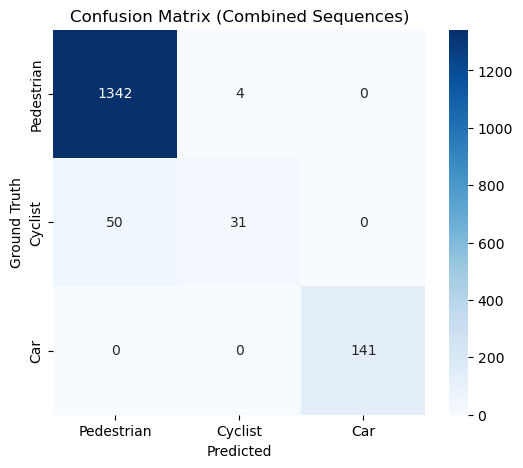

In [56]:
# Show confusion matrix

plt.figure(figsize=(6,5))
sns.heatmap(
    combined_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[INT_TO_CLASS_NAMES[i] for i in range(3)],
    yticklabels=[INT_TO_CLASS_NAMES[i] for i in range(3)],
)
plt.xlabel("Predicted")
plt.ylabel("Ground Truth")
plt.title("Confusion Matrix (Combined Sequences)")
plt.show()


# Get visualization of predictions for report


Selected Correct Frames


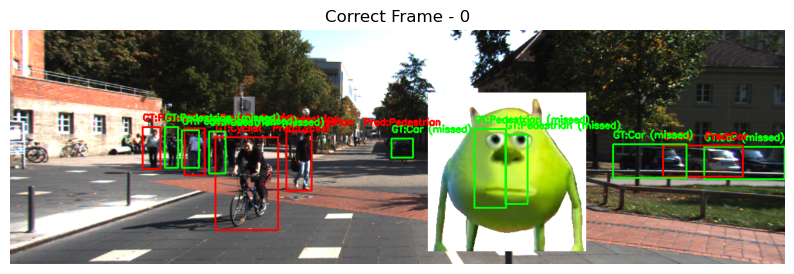

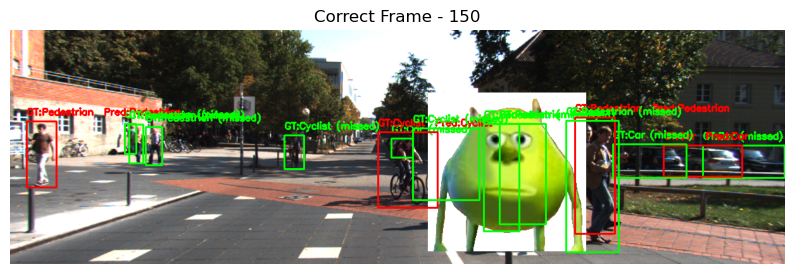


Selected Incorrect Frames


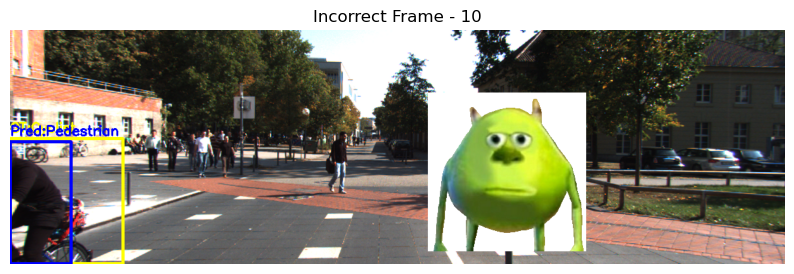

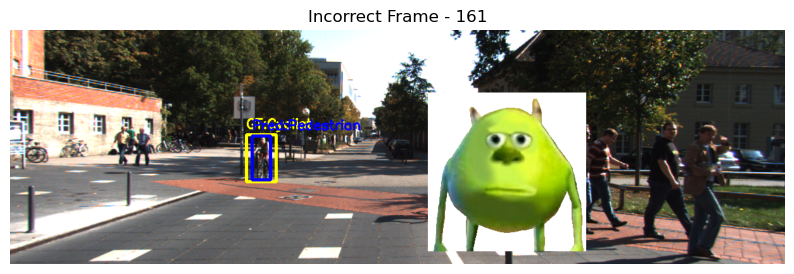

In [57]:
model = YOLO("yolov8n.pt")

img_folder = img_folder_seq_2
labels_path = labels_path_seq_2

img_paths = sorted(glob.glob(img_folder))

correct_frames = []   
wrong_frames = []     
MIN_FRAME_GAP = 150  # Just to ensure we get a bit different images


# We retrieve two different images from each of the cases
# Two images of correct predictions, and two of incorrect
for frame_path in img_paths:

    filename = os.path.basename(frame_path)
    frame_id = int(os.path.splitext(filename)[0])

    correct, wrong, num_gt, num_matched, matches_info = evaluate_frame(
        frame_path, frame_id, labels_path, model
    )

    if wrong == 0:
        if len(correct_frames) == 0:
            correct_frames.append((frame_id, matches_info))
        else:
            if frame_id - correct_frames[0][0] >= MIN_FRAME_GAP and len(correct_frames) < 2:
                correct_frames.append((frame_id, matches_info))

    if wrong > 0:
        if len(wrong_frames) == 0:
            wrong_frames.append((frame_id, matches_info))
        else:
            if frame_id - wrong_frames[0][0] >= MIN_FRAME_GAP and len(wrong_frames) < 2:
                wrong_frames.append((frame_id, matches_info))

    # Stop when we have 2 of each
    if len(correct_frames) == 2 and len(wrong_frames) == 2:
        break

# Plot them
print("\nSelected Correct Frames")
for (fid, matches_info) in correct_frames:

    frame_path = f"34759_final_project_rect/seq_02/image_02/data/{fid:010d}.png"

    img = visualize_matches(
        frame_path,
        fid,
        labels_path,
        model,
        matches_info,
        show_only_incorrect=False
    )

    plt.figure(figsize=(10,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Correct Frame - {fid}")
    plt.show()


print("\nSelected Incorrect Frames")
for (fid, matches_info) in wrong_frames:

    frame_path = f"34759_final_project_rect/seq_02/image_02/data/{fid:010d}.png"

    img = visualize_matches(
        frame_path,
        fid,
        labels_path,
        model,
        matches_info,
        show_only_incorrect=True     # We only show incorrect frames
    )

    plt.figure(figsize=(10,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Incorrect Frame - {fid}")
    plt.show()


# Testing on Sequence 3

In [58]:
# Helper visualization function for when we have no lables
def visualize_yolo_only(frame_path, model):
    img = cv2.imread(frame_path)
    result = model(frame_path, conf=0.5, verbose=False)[0]

    cls_map = INT_TO_CLASS_NAMES

    for box, cls in zip(result.boxes.xyxy.cpu().numpy(), 
                        result.boxes.cls.cpu().numpy()):
        
        if cls not in [0, 1, 2]:
            continue
        
        x1, y1, x2, y2 = map(int, box)
        cls = int(cls)

        # YOLO classes 0,1,2 = person, bicycle, car
        colors = {
            0: (0,255,0),   # green - person
            1: (255,0,255), # magenta - bicycle
            2: (0,0,255),   # red - car
        }
        color = colors.get(cls, (255,255,255))

        cls = cls_map[cls]

        cv2.rectangle(img, (x1,y1), (x2,y2), color, 2)
        cv2.putText(img, f"{cls}", (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    return img, len(result.boxes)

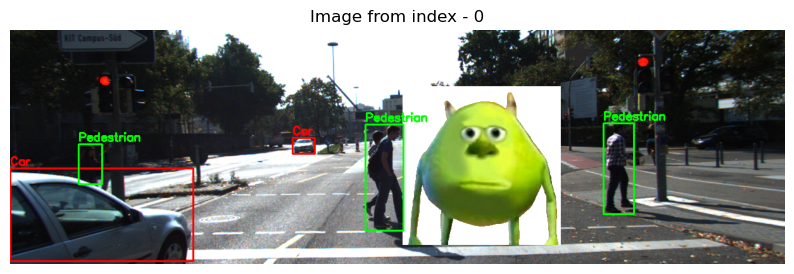

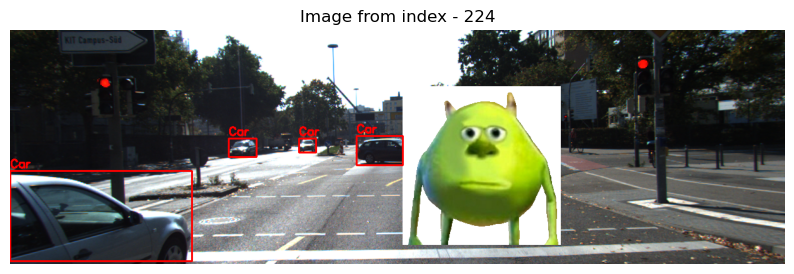

In [59]:
model = YOLO("yolov8n.pt")

img_folder = "34759_final_project_rect/seq_03/image_02/data/*.png"
img_paths = sorted(glob.glob(img_folder))

frames = []     
MIN_FRAME_GAP = 150   # ensure frames several seconds apart

for frame_path in img_paths:

    filename = os.path.basename(frame_path)
    frame_id = int(os.path.splitext(filename)[0])

    img, num_det = visualize_yolo_only(frame_path, model)

    # We pick frames with mulitple predictions for better visualization
    if num_det >= 6:
        if len(frames) == 0:
            frames.append((frame_id, img))
        else:
            if frame_id - frames[0][0] >= MIN_FRAME_GAP and len(frames) < 2:
                frames.append((frame_id, img))

    if len(frames) == 2:
        break

for fid, img in frames:
    plt.figure(figsize=(10,6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Image from index - {fid}")
    plt.show()

# Make video of predictions on the test set

In [60]:
# Helper for annotating without predictions
def annotate_frame_yolo(frame_path, model):
    img = cv2.imread(frame_path)
    result = model(frame_path, conf=0.5, verbose=False)[0]

    cls_map = INT_TO_CLASS_NAMES

    colors = {
        0: (0,255,0),    # green  - pedestrian
        1: (255,0,255),  # magenta - cyclist
        2: (0,0,255)     # red - car
    }

    for box, cls in zip(result.boxes.xyxy.cpu().numpy(),
                        result.boxes.cls.cpu().numpy()):

        cls = int(cls)
        if cls not in [0, 1, 2]:
            continue

        x1, y1, x2, y2 = map(int, box)
        label = cls_map[cls]
        color = colors[cls]

        # Draw box
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        # Draw label
        cv2.putText(img, label, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    return img

In [61]:
model = YOLO("yolov8n.pt")

img_folder = "34759_final_project_rect/seq_03/image_02/data/*.png"
img_paths = sorted(glob.glob(img_folder))


video = []   # store frames

print("Processing frames...")

for frame_path in img_paths:
    annotated = annotate_frame_yolo(frame_path, model)
    video.append(annotated)

print("Finished processing frames.")


frame_height, frame_width, _ = video[0].shape
video_filename = "task2_sequence_03.mp4"

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = 10

out = cv2.VideoWriter(video_filename, fourcc, fps,
                      (frame_width, frame_height))

for frame in video:
    out.write(frame)

out.release()

print(f"Saved video as: {video_filename}")


Processing frames...
Finished processing frames.
Saved video as: task2_sequence_03.mp4
